# Modelo Gradient Boosting

## Importar librerías

In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


## Cargando la tabla limpia

In [45]:
df = pd.read_csv("archive/processed/diabetes_clean.csv")

In [46]:
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Risk_Group
0,0,1,1,1,40.0,1,0,0,0,0,...,0,5,18.0,15.0,1,0,9,4,3,0
1,0,0,0,0,25.0,1,0,0,1,0,...,1,3,0.0,0.0,0,0,7,6,1,0
2,0,1,1,1,28.0,0,0,0,0,1,...,1,5,30.0,30.0,1,0,9,4,8,0
3,0,1,0,1,27.0,0,0,0,1,1,...,0,2,0.0,0.0,0,0,11,3,6,0
4,0,1,1,1,24.0,0,0,0,1,1,...,0,2,3.0,0.0,0,0,11,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229776,0,1,1,1,45.0,0,0,0,0,1,...,0,3,0.0,5.0,0,1,5,6,7,0
229777,2,1,1,1,18.0,0,0,0,0,0,...,0,4,0.0,0.0,1,0,11,2,4,1
229778,0,0,0,1,28.0,0,0,0,1,1,...,0,1,0.0,0.0,0,0,2,5,2,0
229779,0,1,0,1,23.0,0,0,0,0,1,...,0,3,0.0,0.0,0,1,7,5,1,0


In [47]:
lower = df["BMI"].quantile(0.01)
upper = df["BMI"].quantile(0.99)
df["BMI"] = df["BMI"].clip(lower, upper)

### Train test Split

In [48]:
# Creando features y target para mi modelo 
features = df.drop(["Diabetes_012","Risk_Group"], axis=1)
target= df["Risk_Group"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.2, 
    stratify= target,
    random_state=42)

### Modelo Gradient Boosting

In [50]:
gb = GradientBoostingClassifier(random_state=42)

In [51]:
cv_scores = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc")

print("ROC-AUC CV mean:", cv_scores.mean())
print("ROC-AUC CV std:", cv_scores.std())

ROC-AUC CV mean: 0.808822703284417
ROC-AUC CV std: 0.0029537728444850044


In [52]:
param_dist = {
    "n_estimators": randint(100, 400),
    "learning_rate": uniform(0.03, 0.12),
    "max_depth": randint(2, 6),
    "min_samples_leaf": randint(1, 10)
}

In [55]:
random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,              # número de combinaciones aleatorias
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1, 
    verbose=1)

In [65]:
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Best params: {'learning_rate': 0.08397049600437187, 'max_depth': 3, 'min_samples_leaf': 4, 'n_estimators': 369}
Best CV score: 0.8092243186838627


In [58]:
best_gb = random_search.best_estimator_

In [59]:
#Predicciones 
y_probs = best_gb.predict_proba(X_test)[:, 1]
y_pred = best_gb.predict(X_test)

print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91     38012
           1       0.59      0.21      0.31      7945

    accuracy                           0.84     45957
   macro avg       0.72      0.59      0.61     45957
weighted avg       0.81      0.84      0.80     45957

Test ROC-AUC: 0.81476945904334


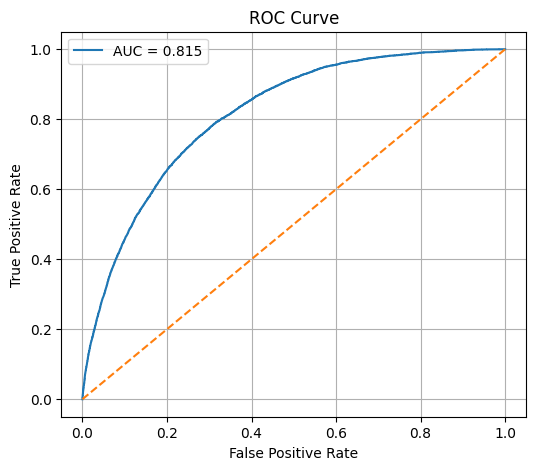

In [62]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [60]:
# Optimización de threshold (max F1)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_threshold = thresholds[np.argmax(f1)]

print("Best threshold:", best_threshold)


Best threshold: 0.2335853719334009


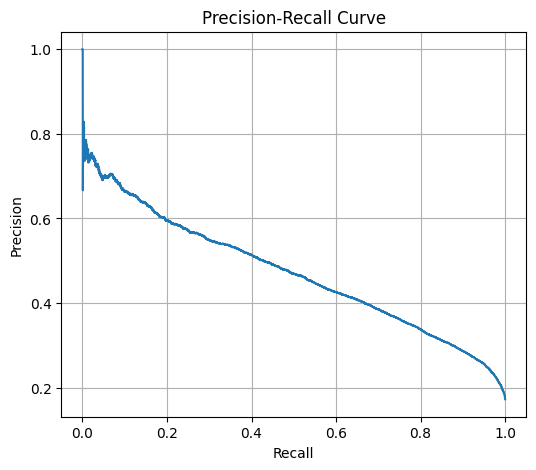

In [61]:
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

In [63]:
y_pred_custom = (y_probs > best_threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85     38012
           1       0.40      0.66      0.50      7945

    accuracy                           0.77     45957
   macro avg       0.66      0.73      0.68     45957
weighted avg       0.83      0.77      0.79     45957



In [64]:
'''
# Guardar modelo
joblib.dump(gb, "model.pkl")

# Guardar threshold óptimo
joblib.dump(best_threshold, "threshold.pkl")

# Guardar orden de columnas
joblib.dump(X_train.columns.tolist(), "columns.pkl")

print("Modelo, threshold y columnas guardados correctamente.")
'''

'\n# Guardar modelo\njoblib.dump(gb, "model.pkl")\n\n# Guardar threshold óptimo\njoblib.dump(best_threshold, "threshold.pkl")\n\n# Guardar orden de columnas\njoblib.dump(X_train.columns.tolist(), "columns.pkl")\n\nprint("Modelo, threshold y columnas guardados correctamente.")\n'

selecciono el randomsearch porque es ligeramente mayor en recall y cuando se trata de datos medicos, lo mas importante es ver el recall, precision y el f1